### Importación de librerías
Primero configuramos el entorno. Usaremos XGBoost configurado para grandes volúmenes de datos y la librería SHAP.

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Inicializar JS para gráficos de SHAP si se usa en Jupyter
shap.initjs()

# Configuración de estilo visual
plt.style.use('seaborn-v0_8-whitegrid')

### Carga de datos y limpieza inicial
Aquí cargaremos el .feather (que es muchísimo más rápido de leer que un CSV). Luego eliminaremos las características que tienen un porcentaje de ceros altísimo (>94%), ya que su varianza es casi nula y no aportan valor discriminativo general, pero sí consumirían recursos valiosos (LUTs/DSPs) en la FPGA.

In [2]:
# 1. Cargar el dataset
print("Cargando dataset...")
df = pd.read_feather('dataset_eda_temp.feather')

# 2. Lista de features a eliminar por ser casi 100% ceros
cols_to_drop = [
    'telnet', 'smtp', 'irc', 'cwr_flag_number', 'ece_flag_number', 
    'dhcp', 'ssh', 'drate', 'arp', 'dns', 'http', 'https'
]

# Eliminar las columnas si existen en el dataframe
df = df.drop(columns=[col for col in cols_to_drop if col in df.columns])
print(f"Dataset cargado. Forma actual: {df.shape}")

Cargando dataset...
Dataset cargado. Forma actual: (46686579, 35)


### Balanceo del Dataset (Muestreo Estratificado)
Vamos a separar el tráfico benigno del malicioso. Como tenemos 1,098,195 registros benignos, extraeremos exactamente esa misma cantidad del tráfico malicioso, pero manteniendo la proporción original de cada ataque usando un muestreo estratificado.

In [3]:
# Separar tráfico benigno y malicioso
df_benign = df[df['label'] == 'BenignTraffic']
df_malicious = df[df['label'] != 'BenignTraffic']

n_benign = len(df_benign)
print(f"Cantidad de tráfico benigno: {n_benign}")

# Muestreo estratificado del tráfico malicioso
# Usamos train_test_split para sacar una muestra de tamaño exacto 'n_benign' 
# manteniendo la proporción de las clases maliciosas.
_, df_malicious_sampled = train_test_split(
    df_malicious,
    test_size=n_benign,
    stratify=df_malicious['label'], # Mantiene las proporciones
    random_state=42
)

print(f"Cantidad de tráfico malicioso muestreado: {len(df_malicious_sampled)}")

# Unir y mezclar (shuffle) el dataset balanceado
df_balanced = pd.concat([df_benign, df_malicious_sampled]).sample(frac=1, random_state=42).reset_index(drop=True)

# Crear la etiqueta binaria: 0 = Benigno, 1 = Malicioso
df_balanced['is_malicious'] = (df_balanced['label'] != 'BenignTraffic').astype(int)

print(f"Dataset balanceado final: {df_balanced.shape}")
print(df_balanced['is_malicious'].value_counts())

Cantidad de tráfico benigno: 1098195
Cantidad de tráfico malicioso muestreado: 1098195
Dataset balanceado final: (2196390, 36)
is_malicious
0    1098195
1    1098195
Name: count, dtype: int64


In [4]:
import gc

del df
del df_benign
del df_malicious
del df_malicious_sampled
gc.collect()

0

### Preparación para Entrenamiento
Separamos en X (características) e y (etiqueta binaria). También hacemos una división de entrenamiento y prueba para validar que el modelo sea bueno antes de confiar en su análisis SHAP.

In [5]:
# Definir X e y (quitamos la columna original 'label' y la nueva 'is_malicious')
X = df_balanced.drop(columns=['label', 'is_malicious'])
y = df_balanced['is_malicious']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamaño de entrenamiento: {X_train.shape}")
print(f"Tamaño de prueba: {X_test.shape}")

Tamaño de entrenamiento: (1757112, 34)
Tamaño de prueba: (439278, 34)


### Entrenamiento del Modelo Proxy (XGBoost)
Puesto que dijiste "no escatimes en uso computacional", vamos a usar todos los 2.2 millones de datos. Para que XGBoost procese esto de forma eficiente y rápida, usamos el método hist (Histogram-based algorithm), que es el estándar de la industria para datasets inmensos.

In [6]:
import matplotlib.pyplot as plt

print("Preparando clasificador XGBoost Binario...")

# Configuramos XGBoost para alto rendimiento
clf = xgb.XGBClassifier(
    n_estimators=150,        # Número de árboles
    max_depth=6,             # Profundidad (suficiente para capturar interacciones)
    learning_rate=0.1,
    tree_method='hist',      # ¡CRUCIAL para datasets grandes!
    n_jobs=-1,               # Usar todos los hilos del CPU
    random_state=42
)

Preparando clasificador XGBoost Binario...


In [7]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
# 1. Ver la configuración y parámetros del modelo antes de entrenar
print("\n--- Hiperparámetros del Modelo ---")
print(clf)
print("----------------------------------\n")


--- Hiperparámetros del Modelo ---
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=150, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)
----------------------------------



In [8]:
print("Iniciando entrenamiento...")
clf.fit(X_train, y_train)

Iniciando entrenamiento...


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [9]:
# Evaluación rápida para asegurar que el modelo aprendió
y_pred = clf.predict(X_test)
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Malicioso (1)']))


Reporte de Clasificación:
               precision    recall  f1-score   support

  Benigno (0)       0.99      1.00      1.00    219639
Malicioso (1)       1.00      0.99      1.00    219639

     accuracy                           1.00    439278
    macro avg       1.00      1.00      1.00    439278
 weighted avg       1.00      1.00      1.00    439278




[+] Modelo guardado exitosamente en: xgb_modelo_binario.json

Generando visualización del árbol...


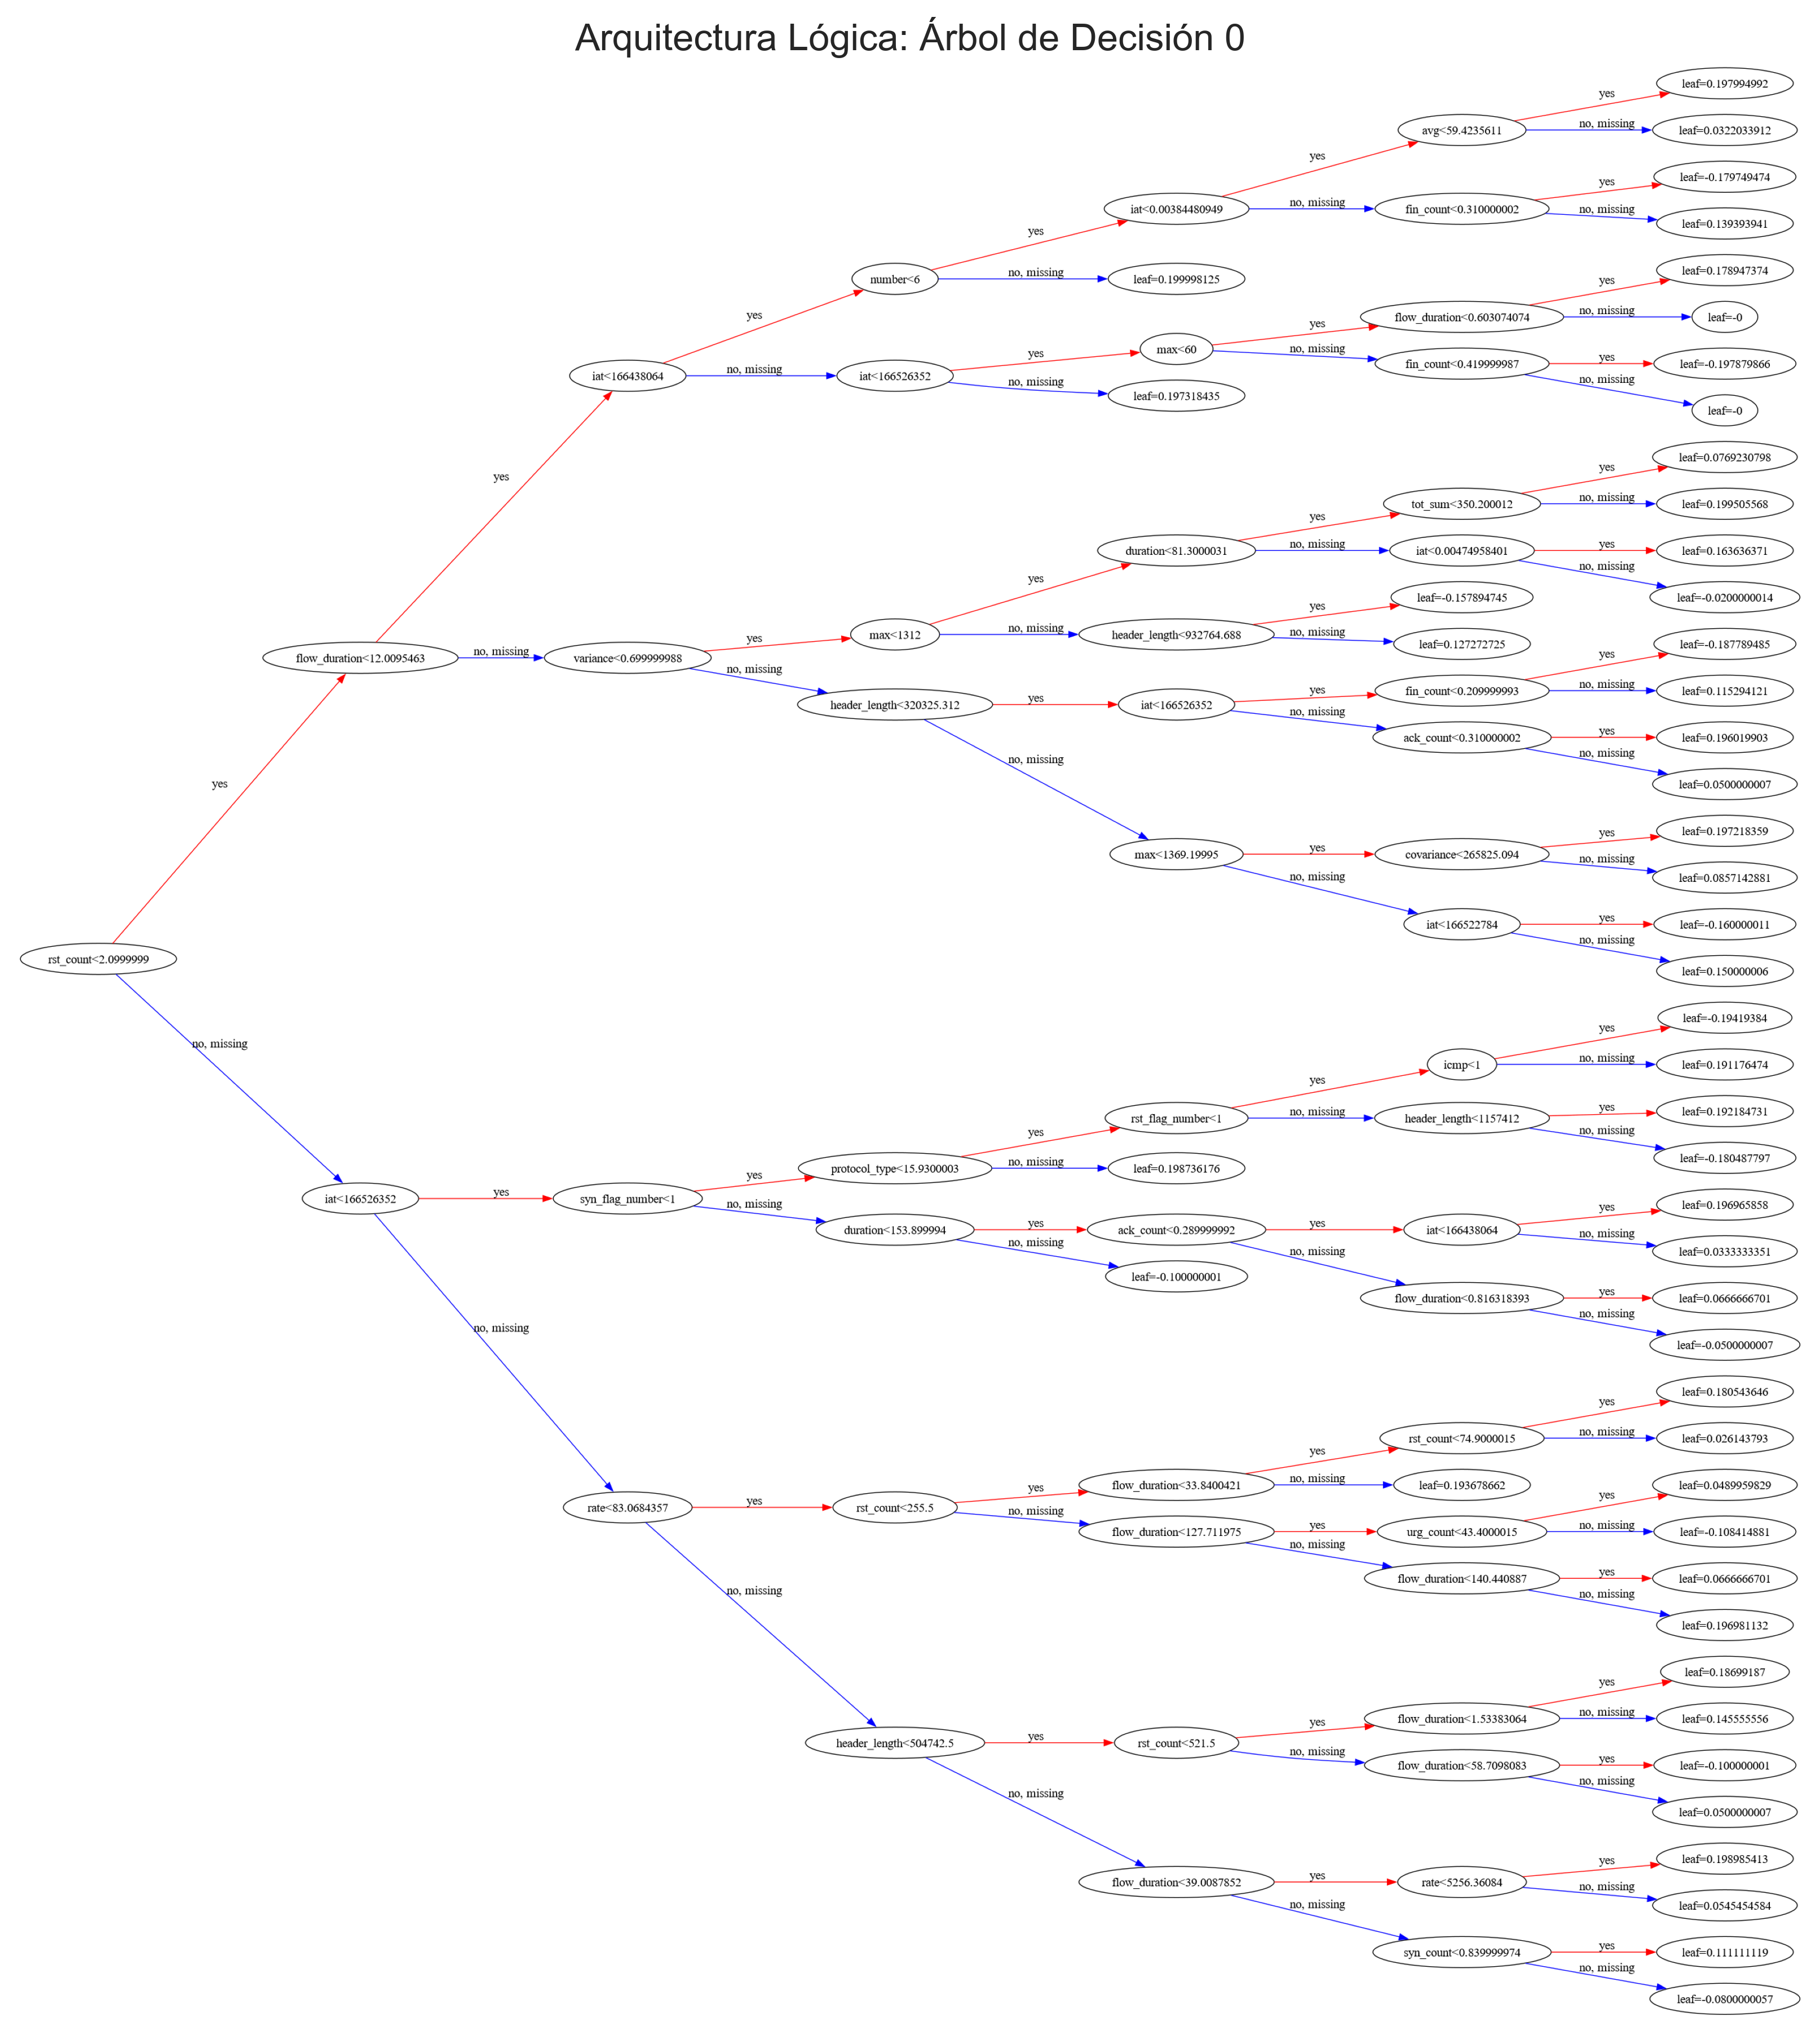

In [10]:
# 2. Guardar el modelo entrenado
# El formato JSON es ideal para mover el modelo entre Windows local y el cluster Linux
model_path = "xgb_modelo_binario.json"
clf.save_model(model_path)
print(f"\n[+] Modelo guardado exitosamente en: {model_path}")

# 3. Visualizar la "arquitectura" (Estructura de un árbol de decisión)
# Dibujamos el primer árbol (índice 0) para ver cómo toma decisiones
print("\nGenerando visualización del árbol...")
try:
    # Ajustamos el tamaño del gráfico (puede ser grande si max_depth=6)
    fig, ax = plt.subplots(figsize=(30, 15), dpi=300)
    
    # rankdir='LR' dibuja el árbol de izquierda a derecha
    xgb.plot_tree(clf, num_trees=0, ax=ax, rankdir='LR') 
    plt.title("Arquitectura Lógica: Árbol de Decisión 0", fontsize=16)
    plt.show()
    
    # Opcional: Guardar la imagen en alta resolución
    fig.savefig("estructura_arbol_0.png", bbox_inches='tight')
    
except Exception as e:
    print(f"\n[!] No se pudo graficar el árbol.")
    print("Para visualizar árboles de XGBoost, necesitas tener instalada la herramienta de sistema 'Graphviz'.")
    print("Puedes instalarla en tu entorno Conda ejecutando en la terminal: conda install -c conda-forge python-graphviz")

In [ ]:
clf = xgb.XGBModel.load_model('xgb_modelo_binario.json')

### Cálculo de Valores SHAP
Este es el núcleo de tu Hito 2. Calcularemos los valores SHAP. Nota importante: Aunque dije que no escatimaremos, procesar SHAP plot de summary en 2.2 millones de filas puede colapsar la RAM a la hora de renderizar el gráfico. Calcular el SHAP TreeExplainer sobre 200,000 muestras es estadísticamente idéntico a hacerlo sobre 2 millones (la convergencia de la importancia se logra mucho antes). Por seguridad gráfica, tomaremos una muestra grande (200k) del set de entrenamiento para generar los gráficos.

In [ ]:
# Tomamos una muestra grande pero segura para la RAM de la tarjeta gráfica/CPU al graficar
X_shap = X_train.sample(n=00000, random_state=42)

print("Calculando valores SHAP (esto puede tomar un par de minutos)...")
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)
print("Cálculo finalizado.")

Calculando valores SHAP (esto puede tomar un par de minutos)...
Cálculo finalizado.


### Visualización e Interpretación de Resultados
Vamos a plotear los dos gráficos más importantes para justificar tu diseño de hardware.

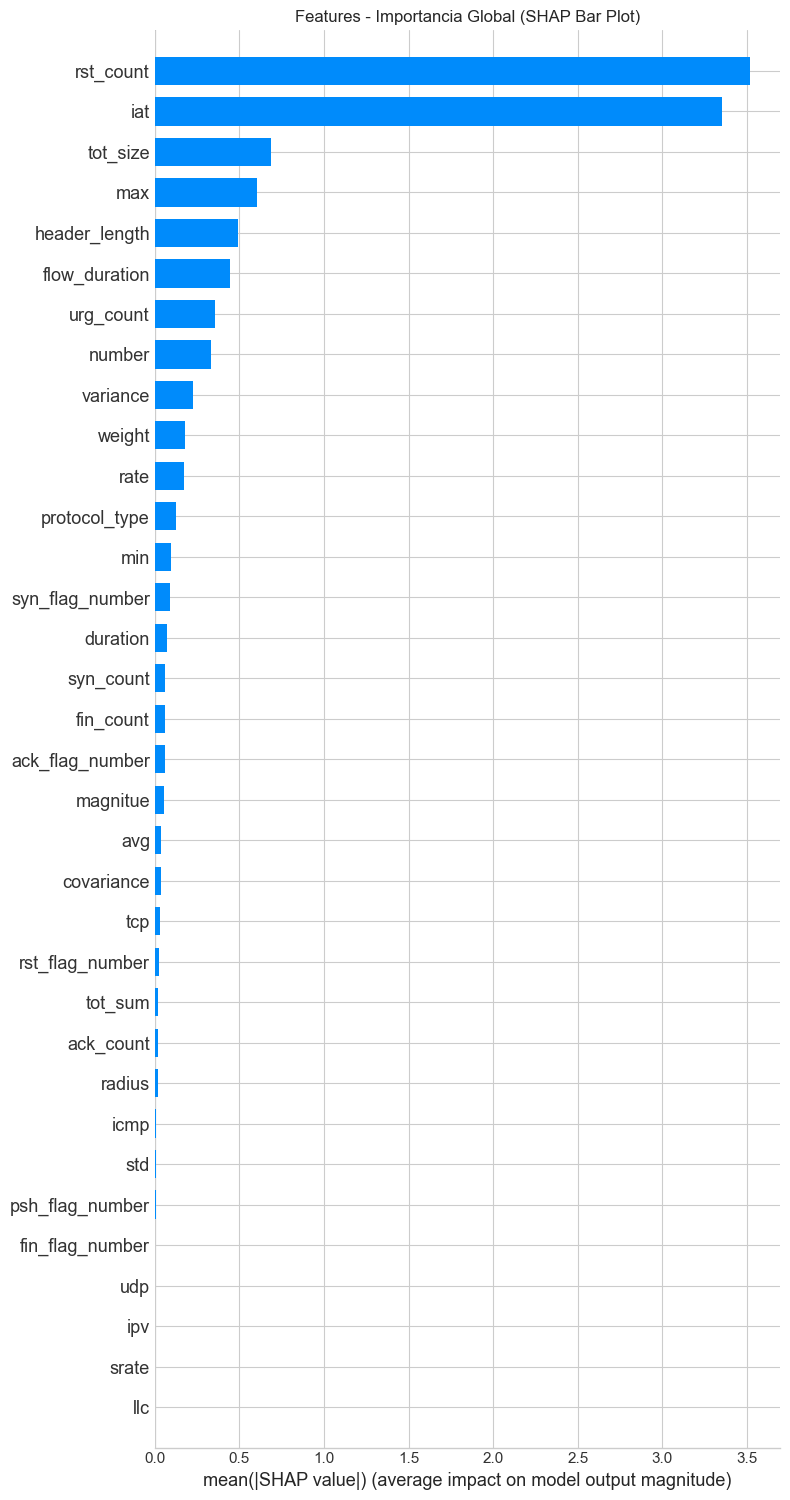

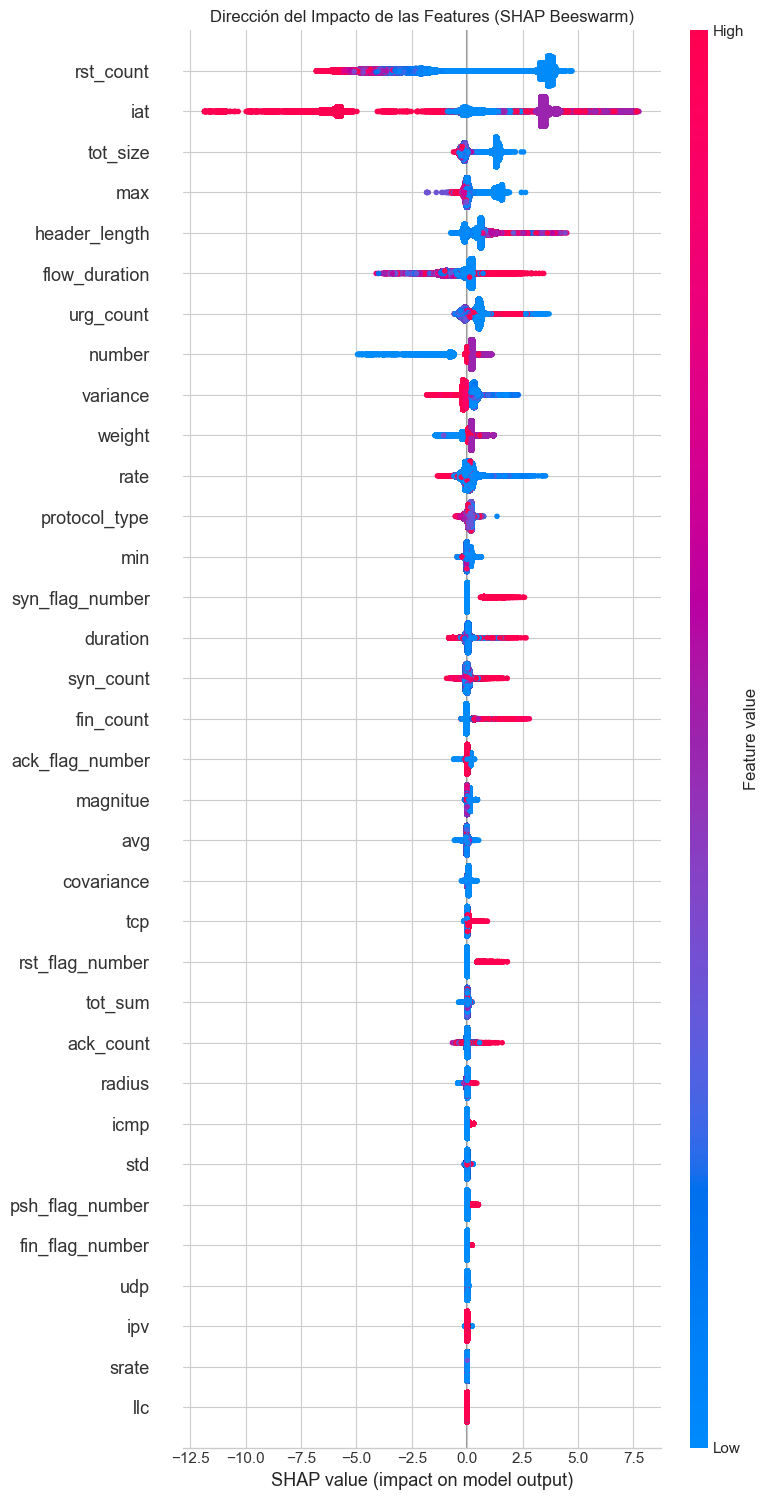

In [15]:
# 1. Gráfico de Barras: Importancia Global Media Absoluta
# ¿Cuáles son las features que MÁS impactan en general?
plt.figure(figsize=(10, 8))
plt.title("Features - Importancia Global (SHAP Bar Plot)")
shap.summary_plot(shap_values, X_shap, plot_type="bar", max_display=36)

# 2. Gráfico Beeswarm (Enjambre): Impacto direccional
# ¿Cómo impactan los valores altos o bajos de una feature en ser o no malicioso?
plt.figure(figsize=(10, 8))
plt.title("Dirección del Impacto de las Features (SHAP Beeswarm)")
shap.summary_plot(shap_values, X_shap, max_display=36)

La "Caída" en el Gráfico de Barras: Observa dónde el tamaño de las barras decrece bruscamente. Por lo general, en tráfico de red, las primeras 10-15 características acumulan la mayor parte del poder predictivo. Tu justificación para la FPGA debe ser: "De las XX características originales, el análisis SHAP demuestra que solo N son necesarias para la clasificación binaria, descartando el resto para ahorrar LUTs/DSPs y reducir la latencia de inferencia."

El patrón de colores en el Beeswarm: Si miras una característica (ej. Tot_size), si los puntos ROJOS (valores altos) están agrupados fuertemente a la derecha (> 0.0 en el eje SHAP), significa que los ataques maliciosos suelen tener tamaños totales muy altos. Esto confirma que el modelo está detectando anomalías físicas reales del tráfico y no memorizando ruido.

¿Qué features importan más? Es probable que dominen características de tasa (rate), conteos de paquetes, banderas TCP y promedios de tamaños. Anota cuáles son, porque estas son las que el módulo de preprocesamiento (que toma la trama Ethernet cruda) deberá extraer primero en la FPGA o en el software embebido.